# Objective 

This project applies Modern Portfolio Theory to construct and compare portfolios using historical asset return data. The aim is to analyse the trade-off between risk and return, generate the efficient frontier, and identify portfolios such as the minimum variance portfolio and maximum Sharpe ratio portfolio.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from scipy.optimize import minimize

# Collect data
tickers = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META']

data = yf.download(
    tickers,
    start="2018-01-01",
    end="2024-12-31",
    auto_adjust=True
)

prices = data["Close"]
prices.head()

[*********************100%***********************]  5 of 5 completed


Ticker,AAPL,AMZN,GOOGL,META,MSFT
Date,,,,,
2018-01-02,40.267078,59.450500,53.188862,180.007401,78.699898
2018-01-03,40.260067,60.209999,54.096317,183.232101,79.066177
2018-01-04,40.447075,60.479500,54.306450,182.894760,79.762054
2018-01-05,40.907578,61.457001,55.026566,185.395096,80.750961
2018-01-08,40.755627,62.343498,55.220837,186.813980,80.833359


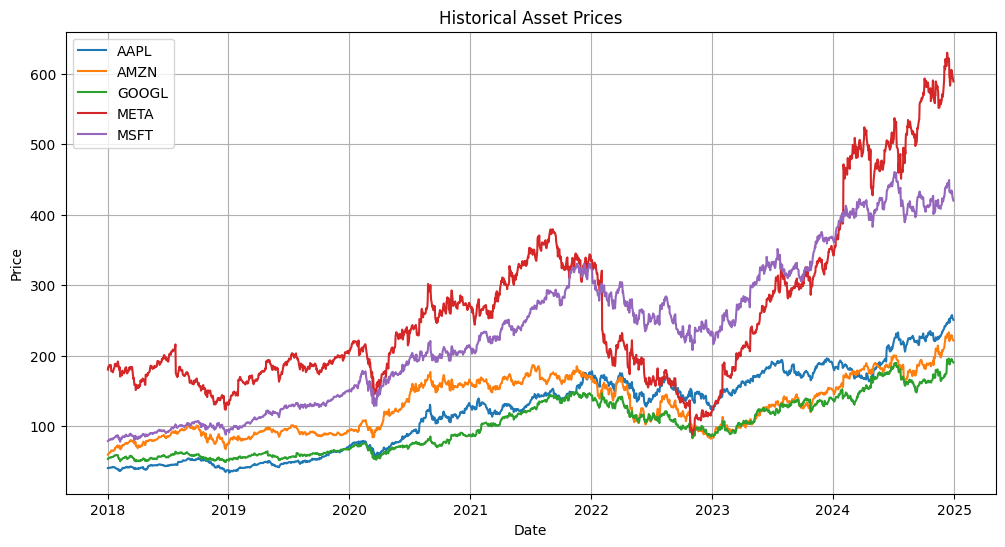

In [3]:
#Plot the price data
plt.figure(figsize=(12, 6))
plt.plot(prices)
plt.title("Historical Asset Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend(prices.columns)
plt.grid(True)
plt.show()

In [4]:
#Compute daily returns
returns = prices.pct_change().dropna()
returns.head()
# Annualize returns and covariance
annual_returns = returns.mean() * 252 # Assuming 252 trading days in a year
cov_matrix = returns.cov() * 252 

# Portfolio theory 

For a portfolio with weights $w$, expected return is:

$E[R_p] = w^T \mu$


Portfolio variance is:

$\sigma_p^2 = w^T \Sigma w$


The Sharpe ratio is:

$\frac{E[R_p] - R_f}{\sigma_p}$


# Simulate random portfolios 

In [5]:
# #Initialise number of portfolios and risk free rate
num_portfolios = 10000
risk_free_rate = 0.03


results = []
# Iterate through random portfolios
for _ in range(num_portfolios):
    # Generate random weights
    weights = np.random.random(len(tickers))
    # Normalize weights to sum to 1
    weights /= np.sum(weights)

    # Calculate portfolio return, volatility, and Sharpe ratio
    portfolio_return = np.dot(weights, annual_returns)
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_volatility
    # Store results
    results.append([portfolio_return, portfolio_volatility, sharpe_ratio, weights])

results_df = pd.DataFrame(
    results,
    columns=["Return", "Volatility", "Sharpe", "Weights"]
)

results_df.head()

,Return,Volatility,Sharpe,Weights
0,0.265142,0.311975,0.753720,"[0.06326326742694403, 0.07217877149388796, 0.1..."
1,0.283525,0.275916,0.918850,"[0.2963954582276283, 0.05121774057396973, 0.02..."
2,0.271946,0.287263,0.842244,"[0.19485036410141499, 0.21115342220214586, 0.0..."
3,0.258985,0.311875,0.734220,"[0.07786214488743734, 0.041569811754668375, 0...."
4,0.253821,0.297250,0.752974,"[0.0909954970374834, 0.3016154868922563, 0.265..."
